### Notebook 17

# **Cross-Validation Neural Networks**

This cross-validation (CV) Notebook should be run at least twice, with *cv_iteration = 2* and *cv_iteration = 3*. The results for *cv_iteration = 1* can be obtained from Notebook 5. 

In [41]:
# Define cross-validation iteration. 
cv_iteration = 3

# Define the train set and test set for this iteration. 
if cv_iteration == 1:
    train_set = 'eegfmriNF'
    validation_set = 'eegNF'
    test_set = 'fmriNF'
elif cv_iteration == 2:
    train_set = 'eegNF'
    validation_set = 'fmriNF'
    test_set = 'eegfmriNF'
elif cv_iteration == 3:
    train_set = 'fmriNF'
    validation_set = 'eegfmriNF'
    test_set = 'eegNF'

## **1. Classification**

We define a **feedforward neural network model** for a classification task, using the **Adam optimizer** and the **binary cross-entropy loss function**. 

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import os
import logging

In [43]:
# Define the raw data path. 
raw_data_path = '../../Neuropolis/ds002336-download/'

# Define the preprocessed data path. 
preprocessed_data_path = '../neuropolis-x1_preprocessed_data/'

# Define the results path. 
results_path = '../neuropolis-x1_results/'

In [44]:
# Load the features, the targets, and the baseline for the classification task. 
with open(preprocessed_data_path + 'dict_targets.p', 'rb') as file:
    dict_targets = pickle.load(file)
with open(preprocessed_data_path + 'classification/dict_features_classification_sequence.p', 'rb') as file:
    dict_features_sequence_class = pickle.load(file)
with open(preprocessed_data_path + 'classification/dict_targets_classification_sequence.p', 'rb') as file:
    dict_targets_sequence_class = pickle.load(file)
with open(preprocessed_data_path + 'classification/dict_baseline_classification_sequence.p', 'rb') as file:
    dict_baseline_sequence_class = pickle.load(file)

In [45]:
# Define the list of subjects, removing sub-xp102 who has a missing condition. 
subjects = ['sub-xp1' + str(x).zfill(2) for x in range(1, 11)]
subjects.remove('sub-xp102')
subject = subjects[0]

# Retrieve the list of all targets. 
targets = list(dict_targets[subject]['eegfmriNF'].keys())

# Select a sequence length. 
selected_sequence_length = 5

# Retrieve the total number of scans. 
nb_scans_total = dict_targets[subject]['eegfmriNF']['Frontal Pole'].shape[0]

# Define the batch size for the neural networks models. 
batch_size = 32

# Define a dictionary to store the FLOPS for each model. 
dict_flops = dict()

In [46]:
# Define a function to run a neural network model for a classification task. 
def run_neural_network_classification(NeuralNetworkModel, dict_features_sequence, dict_targets_sequence, dict_baseline_sequence):

    # Define the dictionaries and the summary DataFrame. 
    dict_models = dict()
    dict_history = dict()
    dict_predictions = dict()
    df_summary = pd.DataFrame()

    # Iterate through all subjects. 
    for subject in subjects:

        # Display current subject. 
        print(subject)

        # Clone the Neural Network model. 
        PredictorBrain = tf.keras.models.clone_model(NeuralNetworkModel)

        # Retrieve the features of the train set, validation set, and test set. 
        X_tr = dict_features_sequence[subject][train_set]
        X_va = dict_features_sequence[subject][validation_set]
        X_te = dict_features_sequence[subject][test_set]

        # Retrieve the targets of the train set, validation set, and test set. 
        Y_tr = dict_targets_sequence[subject][train_set]
        Y_va = dict_targets_sequence[subject][validation_set]
        Y_te = dict_targets_sequence[subject][test_set]

        # Retrieve the baseline of the train set and determine the baseline accuracy. 
        Baseline = dict_baseline_sequence[subject][train_set]
        accuracy_baseline = np.mean(Baseline == Y_te)

        # Rescale features variables. 
        scaler = StandardScaler()
        X_tr_standardized = scaler.fit_transform(X_tr)
        X_va_standardized = scaler.transform(X_va)
        X_te_standardized = scaler.transform(X_te)

        # End training when accuracy stops improving. 
        early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 6, 
                                                          restore_best_weights = True)

        # Define the loss function, optimizer, and metrics to track during training. 
        PredictorBrain.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001), 
                               loss = 'binary_crossentropy', metrics = ['binary_accuracy'])

        # Fit the model. 
        NeuralNetworkHistory = PredictorBrain.fit(
            x = X_tr_standardized, y = Y_tr,
            validation_data = (X_va_standardized, Y_va), 
            batch_size = batch_size, epochs = 50,
            shuffle = True, callbacks = [early_stopping], verbose = 0
        )

        # Evaluate the test accuracy. 
        (loss_test, accuracy_test) = PredictorBrain.evaluate(X_te_standardized, Y_te, batch_size = batch_size)
        print(f'test loss: {loss_test:.4f}, test accuracy: {accuracy_test:.4f}')

        # Compute the predictions from the neural network. 
        Y_pred = PredictorBrain.predict(X_te_standardized)

        # Convert the probabilities to binary predictions. 
        Y_pred_binary = (Y_pred > 0.5).astype(int)

        # Store the performance metrics and the shapes of the arrays in the DataFrame. 
        df_summary.loc[subject, 'loss_train'] = NeuralNetworkHistory.history['loss'][-1]
        df_summary.loc[subject, 'loss_valid'] = NeuralNetworkHistory.history['val_loss'][-1]
        df_summary.loc[subject, 'loss_test'] = loss_test
        df_summary.loc[subject, 'accuracy_train'] = NeuralNetworkHistory.history['binary_accuracy'][-1]
        df_summary.loc[subject, 'accuracy_valid'] = NeuralNetworkHistory.history['val_binary_accuracy'][-1]
        df_summary.loc[subject, 'accuracy_test'] = accuracy_test
        df_summary.loc[subject, 'accuracy_baseline'] = accuracy_baseline
        df_summary.loc[subject, 'above_baseline'] = str(accuracy_test > accuracy_baseline)
        df_summary.loc[subject, 'X_tr.shape'] = str(X_tr_standardized.shape)
        df_summary.loc[subject, 'X_va.shape'] = str(X_va_standardized.shape)
        df_summary.loc[subject, 'X_te.shape'] = str(X_te_standardized.shape)
        df_summary.loc[subject, 'Y_tr.shape'] = str(Y_tr.shape)
        df_summary.loc[subject, 'Y_va.shape'] = str(Y_va.shape)
        df_summary.loc[subject, 'Y_te.shape'] = str(Y_te.shape)

        # Store the trained model, the model history, and the predictions in the dictionary. 
        dict_models[subject] = PredictorBrain
        dict_history[subject] = NeuralNetworkHistory
        dict_predictions[subject] = Y_pred_binary
    
    return dict_models, dict_history, dict_predictions, df_summary

In [47]:
# Define a function to plot the results of the neural network training. 
def plot_neural_network_classification(dict_history_class, title):
    
    # Display the graph. 
    fig, axes = plt.subplots(nrows = 9, ncols = 2, figsize = (12, 52))
    fig.suptitle(title, fontsize = 14, y = 0.895)
    subject_index = 0

    # Iterate through all subjects. 
    for subject in subjects:

        # Retrieve the history. 
        NeuralNetworkHistory = dict_history_class[subject]

        # Plot loss values. 
        axes[subject_index, 0].plot(NeuralNetworkHistory.history['loss'], label = 'train loss', color = 'blue')
        axes[subject_index, 0].plot(NeuralNetworkHistory.history['val_loss'], label = 'val loss', color = 'green')
        axes[subject_index, 0].set_title(str(subject) + ' valid. loss: {:.3f} (mean last 3)'.format(
            np.mean(NeuralNetworkHistory.history['val_loss'][-3:]) # Take the mean of the last three values. 
        ))
        axes[subject_index, 0].set_xlabel('Epoch')
        axes[subject_index, 0].set_ylabel('Loss value')
        axes[subject_index, 0].legend()

        # Plot accuracy values. 
        axes[subject_index, 1].plot(NeuralNetworkHistory.history['binary_accuracy'], label = 'train acc', color = 'blue')
        axes[subject_index, 1].plot(NeuralNetworkHistory.history['val_binary_accuracy'], label = 'val acc', color = 'green')
        axes[subject_index, 1].set_title(str(subject) + ' valid. accuracy: {:.3f} (mean last 3)'.format(
            np.mean(NeuralNetworkHistory.history['val_binary_accuracy'][-3:]) # Take the mean of the last three values. 
        ))
        axes[subject_index, 1].set_xlabel('Epoch')
        axes[subject_index, 1].set_ylabel('Accuracy')
        axes[subject_index, 1].legend();

        # Increment. 
        subject_index += 1

In [48]:
# Define the neural network model. 
tf.random.set_seed(0)
NeuralNetworkModel = tf.keras.Sequential()
input_dim = dict_features_sequence_class[subject]['eegfmriNF'].shape[1]

# Input layer. 
NeuralNetworkModel.add(tf.keras.layers.InputLayer(shape = (input_dim, )))

# Dense layer. 
NeuralNetworkModel.add(tf.keras.layers.Dense(
    units = 4096, activation = tf.keras.activations.relu, 
    kernel_initializer = tf.keras.initializers.VarianceScaling(scale = 2.0, seed = 0),
    kernel_regularizer = tf.keras.regularizers.l2(0.01), bias_regularizer = tf.keras.regularizers.l2(0.01)
    ))
NeuralNetworkModel.add(tf.keras.layers.Dropout(0.5))

# Dense layer. 
NeuralNetworkModel.add(tf.keras.layers.Dense(
    units = 512, activation = tf.keras.activations.relu, 
    kernel_initializer = tf.keras.initializers.VarianceScaling(scale = 2.0, seed = 0),
    kernel_regularizer = tf.keras.regularizers.l2(0.01), bias_regularizer = tf.keras.regularizers.l2(0.01)
    ))
NeuralNetworkModel.add(tf.keras.layers.Dropout(0.5))

# Output layer. 
NeuralNetworkModel.add(tf.keras.layers.Dense(
    units = len(targets), activation = tf.keras.activations.sigmoid,
    kernel_initializer = tf.keras.initializers.VarianceScaling(scale = 1.0, seed = 0)))

# Print network summary. 
NeuralNetworkModel.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 4096)           │     9,293,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 49)             │        25,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,416,625 (43.55 MB)

 Trainable params: 11,416,625 (43.55 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Run the neural network model. 
dict_models_class, dict_history_class, dict_predictions_class, df_summary_class = run_neural_network_classification(NeuralNetworkModel, 
                                                                                                                    dict_features_sequence_class, 
                                                                                                                    dict_targets_sequence_class, 
                                                                                                                    dict_baseline_sequence_class)

sub-xp101
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.5264 - loss: 0.9861 
test loss: 0.9963, test accuracy: 0.5184
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
sub-xp103
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.5316 - loss: 0.9899 
test loss: 0.9855, test accuracy: 0.5270
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
sub-xp104
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.5304 - loss: 0.9887 
test loss: 0.9910, test accuracy: 0.5289
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
sub-xp105
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.4848 - loss: 1.0466 
test loss: 1.0385, test accuracy: 0.4905
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
sub-xp106
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.5147 - loss: 1.0151 
test loss: 1.0106, test accuracy: 0.5193
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
sub-xp107
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.5222 - loss: 1.0389 
test loss: 1.0443, test accuracy: 0.5199
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6m

In [50]:
# Display the results. 
print('Neural Networks: Classification')
df_summary_class

Neural Networks: Classification


,loss_train,loss_valid,loss_test,accuracy_train,accuracy_valid,accuracy_test,accuracy_baseline,above_baseline,X_tr.shape,X_va.shape,X_te.shape,Y_tr.shape,Y_va.shape,Y_te.shape
sub-xp101,0.812656,1.057751,0.996344,0.744477,0.508521,0.518409,0.502946,True,"(194, 2268)","(194, 2268)","(194, 2268)","(194, 49)","(194, 49)","(194, 49)"
sub-xp103,0.774401,0.953369,0.985483,0.742373,0.562066,0.527036,0.492531,True,"(194, 2268)","(194, 2268)","(194, 2268)","(194, 49)","(194, 49)","(194, 49)"
sub-xp104,0.887523,1.024252,0.991035,0.698927,0.517989,0.528929,0.501473,True,"(194, 2268)","(194, 2268)","(194, 2268)","(194, 49)","(194, 49)","(194, 49)"
sub-xp105,0.876607,1.124246,1.038503,0.761203,0.524511,0.490532,0.503156,False,"(194, 2268)","(194, 2268)","(194, 2268)","(194, 49)","(194, 49)","(194, 49)"
sub-xp106,0.856604,1.036614,1.010611,0.713023,0.549758,0.519251,0.494109,True,"(194, 2268)","(194, 2268)","(194, 2268)","(194, 49)","(194, 49)","(194, 49)"
sub-xp107,0.783325,1.007762,1.044294,0.765516,0.568378,0.519882,0.499369,True,"(194, 2268)","(194, 2268)","(194, 2268)","(194, 49)","(194, 49)","(194, 49)"
sub-xp108,0.888411,1.031824,0.995505,0.682937,0.540606,0.510730,0.496213,True,"(194, 2268)","(194, 2268)","(194, 2268)","(194, 49)","(194, 49)","(194, 49)"
sub-xp109,0.897985,1.026638,1.009907,0.714286,0.533137,0.520093,0.494530,True,"(194, 2268)","(194, 2268)","(194, 2268)","(194, 49)","(194, 49)","(194, 49)"
sub-xp110,0.842186,1.133456,1.104254,0.785083,0.506101,0.506627,0.505996,True,"(194, 2268)","(194, 2268)","(194, 2268)","(194, 49)","(194, 49)","(194, 49)"


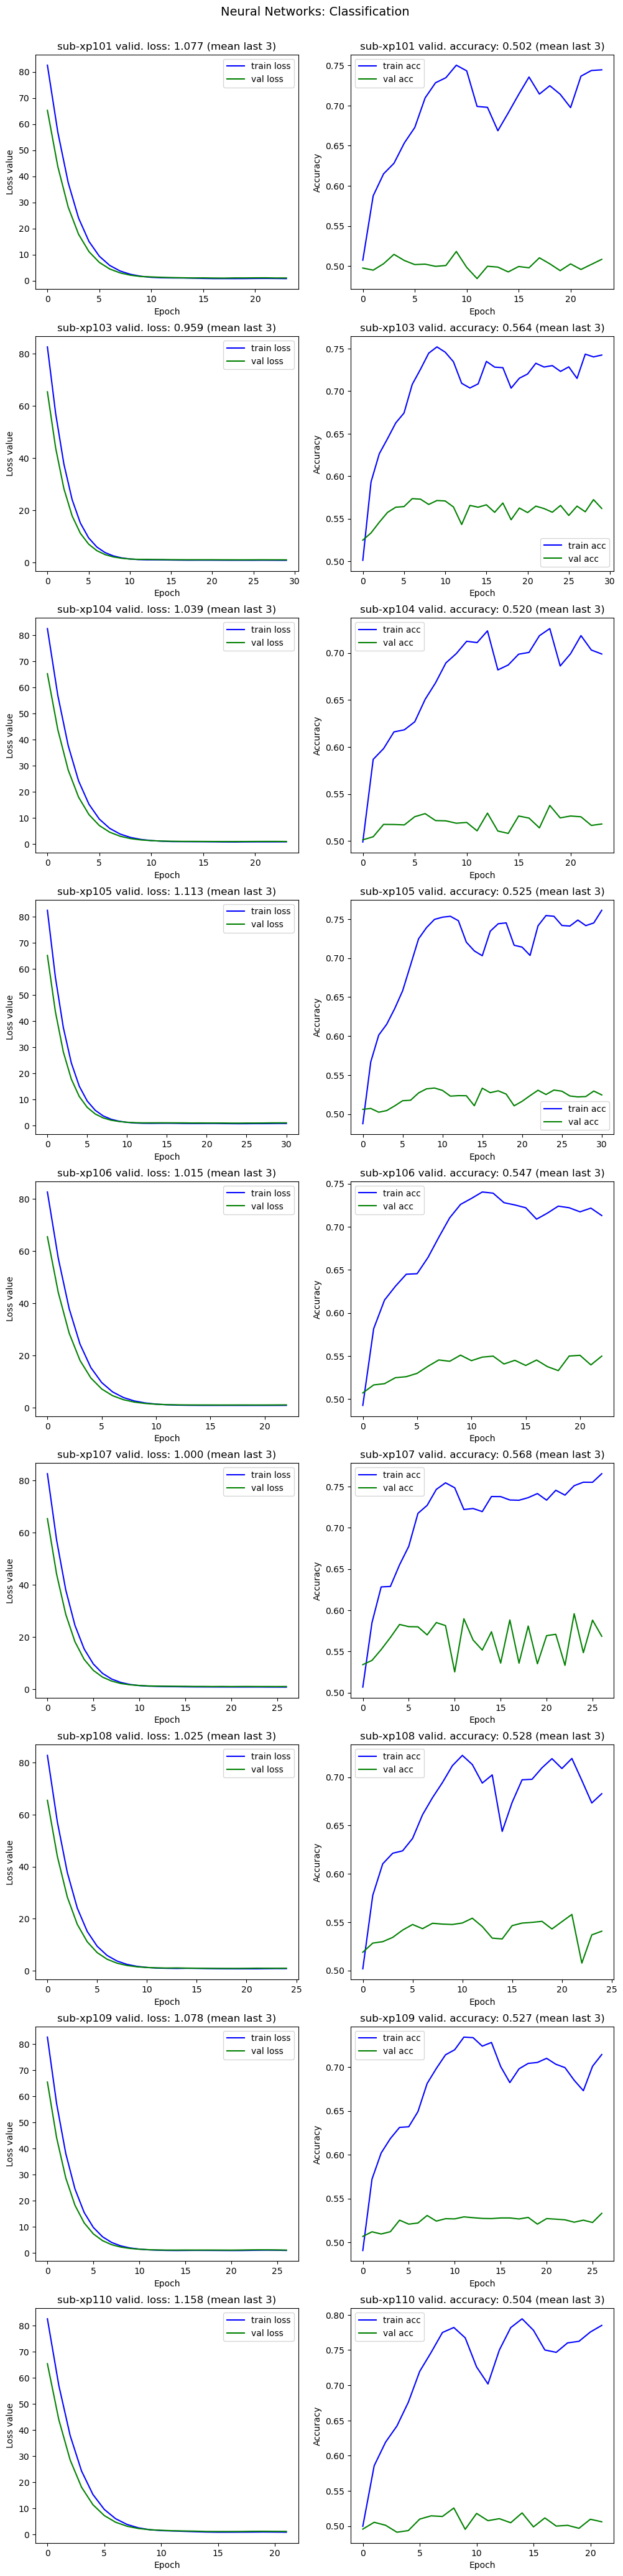

In [51]:
# Display the results. 
plot_neural_network_classification(dict_history_class, title = 'Neural Networks: Classification')

In [52]:
# Define a function to measure the FLOPs of a model. 
def get_flops(model, input_shape):

    # Retrieve the graph of the concrete function. 
    concrete_func = tf.function(model).get_concrete_function(tf.TensorSpec(input_shape, tf.float32))
    graph = concrete_func.graph

    # Measure the FLOPs. 
    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(graph = graph,
                                          run_meta = run_meta,
                                          cmd = 'op',
                                          options = opts)

    return flops.total_float_ops

In [53]:
# Suppress TensorFlow warnings. 
tf.get_logger().setLevel(logging.ERROR)

# Measure the FLOPs of the model. 
input_shape = (1, input_dim)  # Batch size = 1. 
flops = get_flops(NeuralNetworkModel, input_shape)


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

In [54]:
# Store and display the number of FLOPs. 
dict_flops['Neural Networks: Classification'] = flops
print('FLOPs per inference:', flops)

FLOPs per inference: 22828593


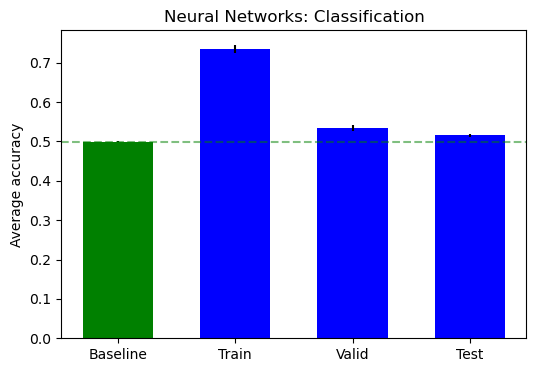

In [55]:
# Retrieve the average accuracy and the standard error of the accuracy. 
acc = [df_summary_class['accuracy_baseline'].mean(), 
       df_summary_class['accuracy_train'].mean(), 
       df_summary_class['accuracy_valid'].mean(), 
       df_summary_class['accuracy_test'].mean()]
acc_se = [np.std(df_summary_class['accuracy_baseline']) / np.sqrt(df_summary_class['accuracy_baseline'].shape[0]), 
          np.std(df_summary_class['accuracy_train']) / np.sqrt(df_summary_class['accuracy_train'].shape[0]), 
          np.std(df_summary_class['accuracy_valid']) / np.sqrt(df_summary_class['accuracy_valid'].shape[0]), 
          np.std(df_summary_class['accuracy_test']) / np.sqrt(df_summary_class['accuracy_test'].shape[0])]

# Display the average accuracy and its standard error in a bar plot. 
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (6, 4))
axes.bar(range(4), acc, width = 0.6, color = ['green', 'blue', 'blue', 'blue'])
axes.errorbar(range(4), acc, yerr = acc_se, fmt = 'None', color = 'black')
axes.axhline(acc[0], 0, 1, color = 'green', linestyle = 'dashed', alpha = 0.5)
axes.set_xticks(range(4), labels = ['Baseline', 'Train', 'Valid', 'Test'])
axes.set_ylabel('Average accuracy')
axes.set_title('Neural Networks: Classification');

## **2. Regression**

We define a **feedforward neural network model** for a regression task, using the **Adam optimizer** and the **mean squared error loss function**. 

In [56]:
# Load the features, the targets, and the baseline for the regression task. 
with open(preprocessed_data_path + 'regression/dict_features_regression_sequence.p', 'rb') as file:
    dict_features_sequence_reg = pickle.load(file)
with open(preprocessed_data_path + 'regression/dict_targets_regression_sequence.p', 'rb') as file:
    dict_targets_sequence_reg = pickle.load(file)
with open(preprocessed_data_path + 'regression/dict_baseline_regression_sequence.p', 'rb') as file:
    dict_baseline_sequence_reg = pickle.load(file)

In [57]:
# Define the Mean Squared Error function. 
def MSE(y, y_pred):
    return np.mean(np.square(y - y_pred))

In [58]:
# Define the Mean Absolute Error function. 
def MAE(y, y_pred):
    return np.mean(np.abs(y - y_pred))

In [59]:
# Define the Residual Sum of Squares function. 
def RSS(y, y_pred):
    return np.sum(np.square(y - y_pred))

In [60]:
# Define a function to run a neural network model for a regression task. 
def run_neural_network_regression(NeuralNetworkModel, dict_features_sequence, dict_targets_sequence, dict_baseline_sequence):

    # Define the dictionaries and the summary DataFrame. 
    dict_models = dict()
    dict_history = dict()
    dict_predictions = dict()
    df_summary = pd.DataFrame()

    # Iterate through all subjects. 
    for subject in subjects:

        # Display current subject. 
        print(subject)

        # Clone the Neural Network model. 
        PredictorBrain = tf.keras.models.clone_model(NeuralNetworkModel)

        # Retrieve the features of the train set, validation set, and test set. 
        X_tr = dict_features_sequence[subject][train_set]
        X_va = dict_features_sequence[subject][validation_set]
        X_te = dict_features_sequence[subject][test_set]

        # Retrieve the targets of the train set, validation set, and test set. 
        Y_tr = dict_targets_sequence[subject][train_set]
        Y_va = dict_targets_sequence[subject][validation_set]
        Y_te = dict_targets_sequence[subject][test_set]

        # Retrieve the baseline of the train set. 
        Baseline = dict_baseline_sequence[subject][train_set]

        # Rescale features variables. 
        scaler = StandardScaler()
        X_tr_standardized = scaler.fit_transform(X_tr)
        X_va_standardized = scaler.transform(X_va)
        X_te_standardized = scaler.transform(X_te)

        # End training when accuracy stops improving. 
        early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 6, 
                                                          restore_best_weights = True)

        # Define the loss function, optimizer, and metrics to track during training. 
        optimizer = tf.keras.optimizers.Adam(learning_rate = 0.005, beta_1 = 0.9)
        PredictorBrain.compile(optimizer = optimizer, loss = 'mse', metrics = [tf.keras.metrics.MeanAbsoluteError()])

        # Fit the model. 
        NeuralNetworkHistory = PredictorBrain.fit(
            x = X_tr_standardized, y = Y_tr,
            validation_data = (X_va_standardized, Y_va), 
            batch_size = batch_size, epochs = 50, 
            shuffle = True, callbacks = [early_stopping], verbose = 0
        )

        # Evaluate the test MSE and MAE. 
        (mse_test, mae_test) = PredictorBrain.evaluate(X_te_standardized, Y_te, batch_size = batch_size)
        print(f'test MSE: {mse_test:.4f}, test MAE: {mae_test:.4f}')

        # Compute the predictions from the neural network. 
        Y_pred = PredictorBrain.predict(X_te_standardized)

        # Evaluate the performance metrics. 
        mse_baseline = MSE(Y_te, Baseline)
        mae_baseline = MAE(Y_te, Baseline)
        rss_baseline = RSS(Y_te, Baseline)
        mse_model = MSE(Y_te, Y_pred)
        mae_model = MAE(Y_te, Y_pred)
        rss_model = RSS(Y_te, Y_pred)
        r2_model = 1 - (rss_model / rss_baseline)

        # Store the performance metrics and the shapes of the arrays in the DataFrame. 
        df_summary.loc[subject, 'mse_train'] = NeuralNetworkHistory.history['loss'][-1]
        df_summary.loc[subject, 'mse_valid'] = NeuralNetworkHistory.history['val_loss'][-1]
        df_summary.loc[subject, 'mse_test'] = mse_test
        df_summary.loc[subject, 'mae_train'] = NeuralNetworkHistory.history['mean_absolute_error'][-1]
        df_summary.loc[subject, 'mae_valid'] = NeuralNetworkHistory.history['val_mean_absolute_error'][-1]
        df_summary.loc[subject, 'mae_test'] = mae_test
        df_summary.loc[subject, 'mae_baseline'] = mae_baseline
        df_summary.loc[subject, 'r2_model'] = r2_model
        df_summary.loc[subject, 'X_tr.shape'] = str(X_tr_standardized.shape)
        df_summary.loc[subject, 'X_va.shape'] = str(X_va_standardized.shape)
        df_summary.loc[subject, 'X_te.shape'] = str(X_te_standardized.shape)
        df_summary.loc[subject, 'Y_tr.shape'] = str(Y_tr.shape)
        df_summary.loc[subject, 'Y_va.shape'] = str(Y_va.shape)
        df_summary.loc[subject, 'Y_te.shape'] = str(Y_te.shape)

        # Store the trained model, the model history, and the predictions in the dictionary. 
        dict_models[subject] = PredictorBrain
        dict_history[subject] = NeuralNetworkHistory
        dict_predictions[subject] = Y_pred
    
    return dict_models, dict_history, dict_predictions, df_summary

In [61]:
# Define a function to plot the results of the neural network training. 
def plot_neural_network_regression(dict_history_reg, title):
    
    # Display the graph. 
    fig, axes = plt.subplots(nrows = 9, ncols = 2, figsize = (12, 52))
    fig.suptitle(title, fontsize = 14, y = 0.895)
    subject_index = 0

    # Iterate through all subjects. 
    for subject in subjects:

        # Retrieve the history. 
        NeuralNetworkHistory = dict_history_reg[subject]

        # Plot MSE values. 
        axes[subject_index, 0].plot(NeuralNetworkHistory.history['loss'], label = 'train MSE', color = 'blue')
        axes[subject_index, 0].plot(NeuralNetworkHistory.history['val_loss'], label = 'val MSE', color = 'green')
        axes[subject_index, 0].set_title(str(subject) + ' valid. MSE: {:.3f} (mean last 3)'.format(
            np.mean(NeuralNetworkHistory.history['val_loss'][-3:]) # Take the mean of the last three values. 
        ))
        axes[subject_index, 0].set_xlabel('Epoch')
        axes[subject_index, 0].set_ylabel('MSE')
        axes[subject_index, 0].legend()

        # Plot MAE values. 
        axes[subject_index, 1].plot(NeuralNetworkHistory.history['mean_absolute_error'], label = 'train MAE', color = 'blue')
        axes[subject_index, 1].plot(NeuralNetworkHistory.history['val_mean_absolute_error'], label = 'val MAE', color = 'green')
        axes[subject_index, 1].set_title(str(subject) + ' valid. MAE: {:.3f} (mean last 3)'.format(
            np.mean(NeuralNetworkHistory.history['val_mean_absolute_error'][-3:]) # Take the mean of the last three values. 
        ))
        axes[subject_index, 1].set_xlabel('Epoch')
        axes[subject_index, 1].set_ylabel('MAE')
        axes[subject_index, 1].legend();

        # Increment. 
        subject_index += 1

In [62]:
# Define the neural network model. 
tf.random.set_seed(0)
NeuralNetworkModel = tf.keras.Sequential()
input_dim = dict_features_sequence_reg[subject]['eegfmriNF'].shape[1]

# Input layer. 
NeuralNetworkModel.add(tf.keras.layers.InputLayer(shape = (input_dim, )))

# Dense layer. 
NeuralNetworkModel.add(tf.keras.layers.Dense(
    units = 4096, activation = tf.keras.activations.relu, 
    kernel_initializer = tf.keras.initializers.VarianceScaling(scale = 2.0, seed = 0),
    kernel_regularizer = tf.keras.regularizers.l2(0.01), bias_regularizer = tf.keras.regularizers.l2(0.01)
    ))
NeuralNetworkModel.add(tf.keras.layers.Dropout(0.5))

# Dense layer. 
NeuralNetworkModel.add(tf.keras.layers.Dense(
    units = 512, activation = tf.keras.activations.relu, 
    kernel_initializer = tf.keras.initializers.VarianceScaling(scale = 2.0, seed = 0),
    kernel_regularizer = tf.keras.regularizers.l2(0.01), bias_regularizer = tf.keras.regularizers.l2(0.01)
    ))
NeuralNetworkModel.add(tf.keras.layers.Dropout(0.5))

# Output layer. 
NeuralNetworkModel.add(tf.keras.layers.Dense(
    units = dict_targets_sequence_reg[subject]['eegfmriNF'].shape[1], 
    ))

# Print network summary. 
NeuralNetworkModel.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 4096)           │     9,293,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 49)             │        25,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,416,625 (43.55 MB)

 Trainable params: 11,416,625 (43.55 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# Run the neural network model. 
dict_models_reg, dict_history_reg, dict_predictions_reg, df_summary_reg = run_neural_network_regression(NeuralNetworkModel, 
                                                                                                        dict_features_sequence_reg, 
                                                                                                        dict_targets_sequence_reg, 
                                                                                                        dict_baseline_sequence_reg)

sub-xp101
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.3114 - mean_absolute_error: 0.7083 
test MSE: 2.2329, test MAE: 0.6749
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
sub-xp103
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.8560 - mean_absolute_error: 0.7830 
test MSE: 3.8142, test MAE: 0.7599
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
sub-xp104
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7978 - mean_absolute_error: 0.6543 
test MSE: 2.8381, test MAE: 0.6635
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
sub-xp105
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.2183 - mean_absolute_error: 0.8750 
test MSE: 3.0368, test MAE: 0.8075
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
sub-xp106
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5019 - mean_absolute_error: 0.8425 
test MSE: 3.3890, test MAE: 0.7989
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
sub-xp107
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4515 - mean_absolute_error: 0.8132 
test MSE: 3.3989, test MAE: 0.7844
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
sub-

In [64]:
# Display the results. 
print('Neural Networks: Regression')
df_summary_reg

Neural Networks: Regression


,mse_train,mse_valid,mse_test,mae_train,mae_valid,mae_test,mae_baseline,r2_model,X_tr.shape,X_va.shape,X_te.shape,Y_tr.shape,Y_va.shape,Y_te.shape
sub-xp101,7.559905,6.826581,2.232903,0.806270,0.783890,0.674945,0.673287,-0.019904,"(195, 2268)","(195, 2268)","(195, 2268)","(195, 49)","(195, 49)","(195, 49)"
sub-xp103,12.190247,10.204271,3.814173,0.875185,0.800458,0.759855,0.764916,-0.002256,"(195, 2268)","(195, 2268)","(195, 2268)","(195, 49)","(195, 49)","(195, 49)"
sub-xp104,11.284707,9.582386,2.838098,0.772879,0.685077,0.663505,0.664922,-0.000261,"(195, 2268)","(195, 2268)","(195, 2268)","(195, 49)","(195, 49)","(195, 49)"
sub-xp105,4.437406,3.649441,3.036768,0.809352,0.797598,0.807526,0.788727,-0.030709,"(195, 2268)","(195, 2268)","(195, 2268)","(195, 49)","(195, 49)","(195, 49)"
sub-xp106,4.627960,4.489956,3.389002,0.786139,0.832812,0.798924,0.794260,-0.010619,"(195, 2268)","(195, 2268)","(195, 2268)","(195, 49)","(195, 49)","(195, 49)"
sub-xp107,5.557651,4.811895,3.398928,0.817101,0.799013,0.784376,0.783694,-0.002811,"(195, 2268)","(195, 2268)","(195, 2268)","(195, 49)","(195, 49)","(195, 49)"
sub-xp108,5.263080,4.716086,3.735034,0.830490,0.819005,0.809417,0.808577,-0.018233,"(195, 2268)","(195, 2268)","(195, 2268)","(195, 49)","(195, 49)","(195, 49)"
sub-xp109,6.665574,7.943540,4.034991,0.815117,0.830493,0.814169,0.813239,-0.005249,"(195, 2268)","(195, 2268)","(195, 2268)","(195, 49)","(195, 49)","(195, 49)"
sub-xp110,5.333415,5.005741,3.273352,0.842011,0.828336,0.786479,0.788212,0.000463,"(195, 2268)","(195, 2268)","(195, 2268)","(195, 49)","(195, 49)","(195, 49)"


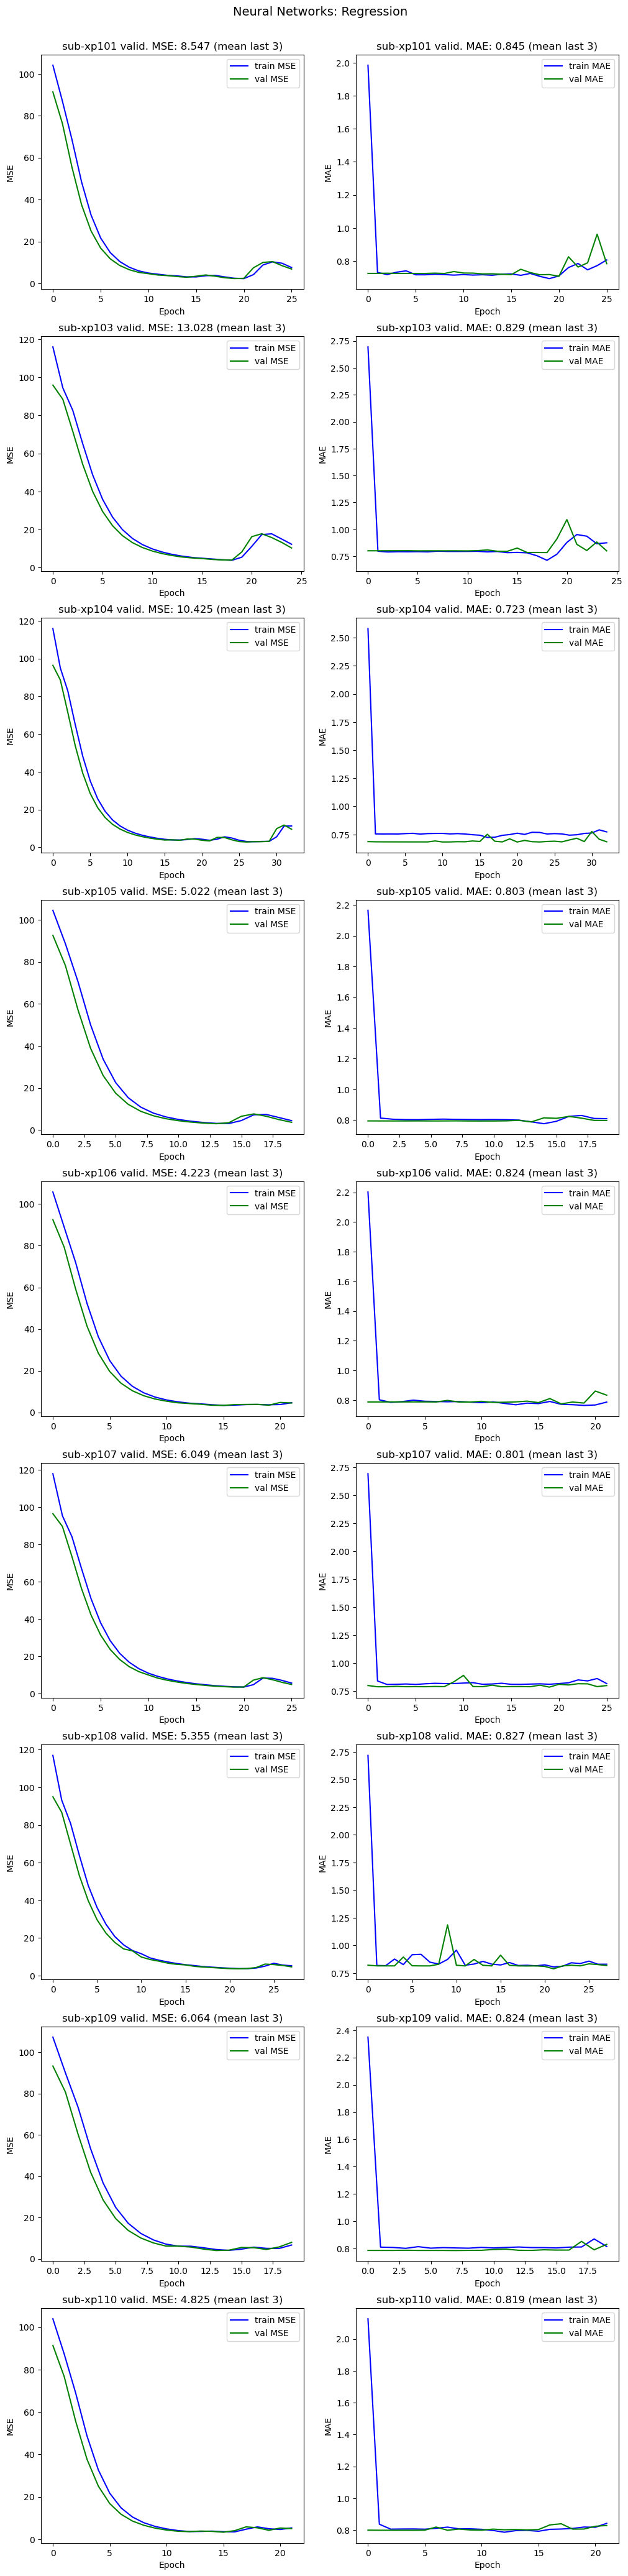

In [65]:
# Display the results. 
plot_neural_network_regression(dict_history_reg, title = 'Neural Networks: Regression')

In [66]:
# Measure the FLOPs of the model. 
input_shape = (1, input_dim)  # Batch size = 1. 
flops = get_flops(NeuralNetworkModel, input_shape)


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

In [67]:
# Store and display the number of FLOPs. 
dict_flops['Neural Networks: Regression'] = flops
print('FLOPs per inference:', flops)

FLOPs per inference: 22828593


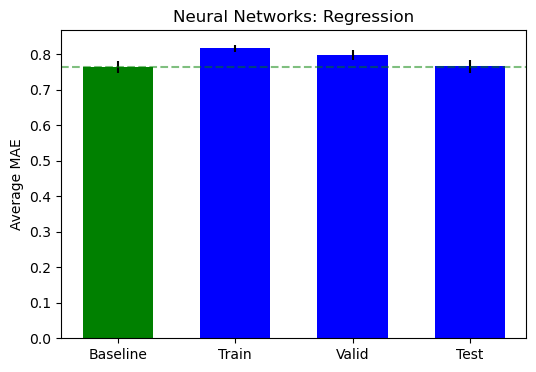

In [68]:
# Retrieve the average MAE and the standard error of the MAE. 
mae = [df_summary_reg['mae_baseline'].mean(), 
       df_summary_reg['mae_train'].mean(), 
       df_summary_reg['mae_valid'].mean(), 
       df_summary_reg['mae_test'].mean()]
mae_se = [np.std(df_summary_reg['mae_baseline']) / np.sqrt(df_summary_reg['mae_baseline'].shape[0]), 
          np.std(df_summary_reg['mae_train']) / np.sqrt(df_summary_reg['mae_train'].shape[0]), 
          np.std(df_summary_reg['mae_valid']) / np.sqrt(df_summary_reg['mae_valid'].shape[0]), 
          np.std(df_summary_reg['mae_test']) / np.sqrt(df_summary_reg['mae_test'].shape[0])]

# Display the average MAE and its standard error in a bar plot. 
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (6, 4))
axes.bar(range(4), mae, width = 0.6, color = ['green', 'blue', 'blue', 'blue'])
axes.errorbar(range(4), mae, yerr = mae_se, fmt = 'None', color = 'black')
axes.axhline(mae[0], 0, 1, color = 'green', linestyle = 'dashed', alpha = 0.5)
axes.set_xticks(range(4), labels = ['Baseline', 'Train', 'Valid', 'Test'])
axes.set_ylabel('Average MAE')
axes.set_title('Neural Networks: Regression');

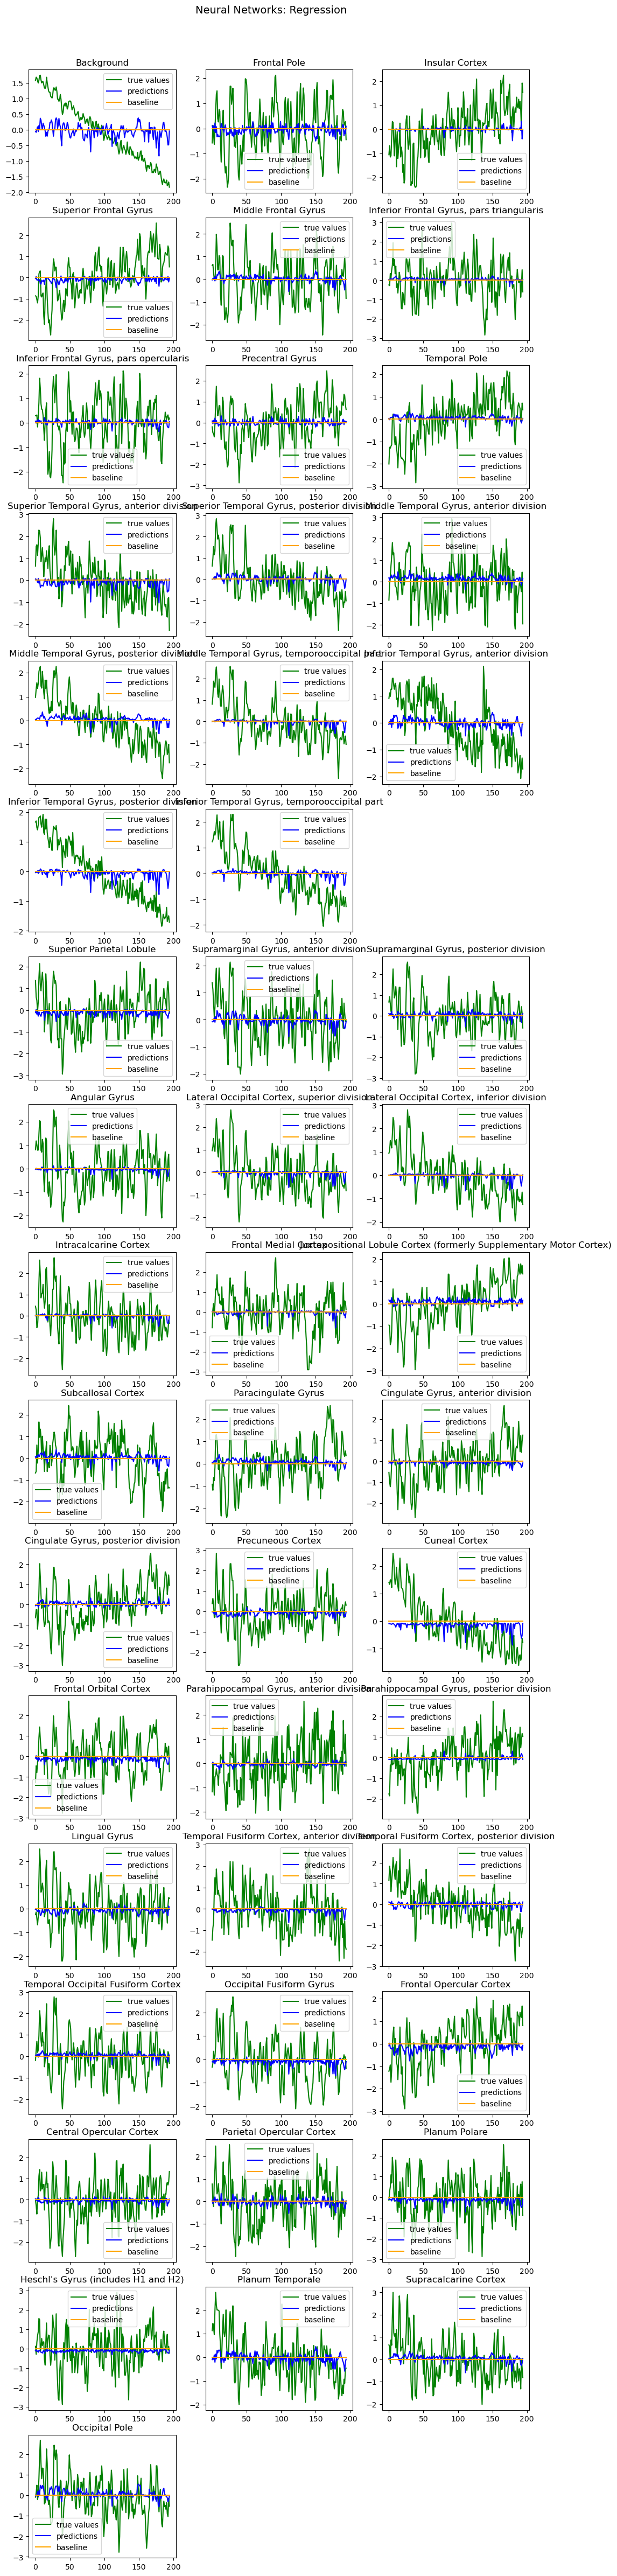

In [69]:
# Select the subject with the best predictions. 
subject = subjects[np.argmax(df_summary_reg['r2_model'])]

# Plot the true values, the predictions, and the baseline for all the targets. 
fig, axes = plt.subplots(nrows = 17, ncols = 3, figsize = (12, 60))
fig.suptitle('Neural Networks: Regression', fontsize = 14, y = 0.9)

# Iterate through all brain regions. 
for brain_region_index in range(len(targets)):

    # Retrieve the true values, the predictions, and the baseline for the selected subject and sequence length. 
    Y_te = dict_targets_sequence_reg[subject][test_set][:, brain_region_index]
    Y_pred = dict_predictions_reg[subject][:, brain_region_index]
    Baseline = dict_baseline_sequence_reg[subject][train_set][:, brain_region_index]

    # Compute the row and column indexes. 
    row_index = brain_region_index // 3
    column_index = brain_region_index % 3

    # Plot the true values, the predictions, and the baseline. 
    axes[row_index, column_index].plot(Y_te,  color = 'green', label = 'true values')
    axes[row_index, column_index].plot(Y_pred,  color = 'blue', label = 'predictions')
    axes[row_index, column_index].plot(Baseline,  color = 'orange', label = 'baseline')
    axes[row_index, column_index].legend()
    axes[row_index, column_index].set_title(targets[brain_region_index])

# Hide empty subplots. 
axes[5, 2].set_visible(False)
axes[16, 1].set_visible(False)
axes[16, 2].set_visible(False)

## **3. Results**

In [70]:
# Define the classification cross-validation results path. 
classification_cv_results_path = results_path + 'classification/cross_validation/cv_iteration_' + str(cv_iteration) + '/'

# Define the regression cross-validation results path. 
regression_cv_results_path = results_path + 'regression/cross_validation/cv_iteration_' + str(cv_iteration) + '/'

In [71]:
# Create directories for the results. 
if not os.path.isdir(classification_cv_results_path + 'neural_networks/'):
    os.mkdir(classification_cv_results_path + 'neural_networks/')
if not os.path.isdir(regression_cv_results_path + 'neural_networks/'):
    os.mkdir(regression_cv_results_path + 'neural_networks/')

# Save the models in the native Keras format. 
for subject in subjects:
    dict_models_class[subject].save(classification_cv_results_path + 'neural_networks/' + subject + '.keras')
    dict_models_reg[subject].save(regression_cv_results_path + 'neural_networks/' + subject + '.keras')

# Save the predictions into Pickle files. 
with open(classification_cv_results_path + 'neural_networks/dict_predictions_neural_networks_class.p', 'wb') as file:
    pickle.dump(dict_predictions_class, file)
with open(regression_cv_results_path + 'neural_networks/dict_predictions_neural_networks_reg.p', 'wb') as file:
    pickle.dump(dict_predictions_reg, file)

# Save the summaries into Pickle files. 
with open(classification_cv_results_path + 'neural_networks/df_summary_neural_networks_class.p', 'wb') as file:
    pickle.dump(df_summary_class, file)
with open(regression_cv_results_path + 'neural_networks/df_summary_neural_networks_reg.p', 'wb') as file:
    pickle.dump(df_summary_reg, file)